In [1]:
import os
import pickle
import pathlib

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import pandas as pd
import pingouin as pg

import statsmodels.formula.api as smf

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice


plt.rcParams['pdf.fonttype']=42
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
sess = u.load_single_day('mCherry9',0)
sess.novel_arm

{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


-1

In [3]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig5_novel_activity_rate')
figdir.mkdir(exist_ok=True, parents=True)

In [4]:
block_rate = stx.novel_activity_rate.BlockTransitionActivityRate(ts_key='F_dff')

4467331.1
4467331.2
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
4467332.1
4467332.2
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
4467333.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


mCherry6
mCherry7
mCherry8
mCherry9
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.2


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.3


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.4
4467975.5
Cre7
Cre9


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:219: RuntimeWarning: Mean of empty slice
  comb = np.nanmean(np.concatenate((data['baseline_act'], data['block_act'])),axis=-1)/base.mean()
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:220: RuntimeWarning: Mean of empty slice
  fam = np.nanmean(data['block_fam_act'], axis=-1)/base.mean()
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:221: RuntimeWarning: Mean of empty slice
  nov = np.nanmean(data['block_nov_act'], axis=-1)/base.mean()


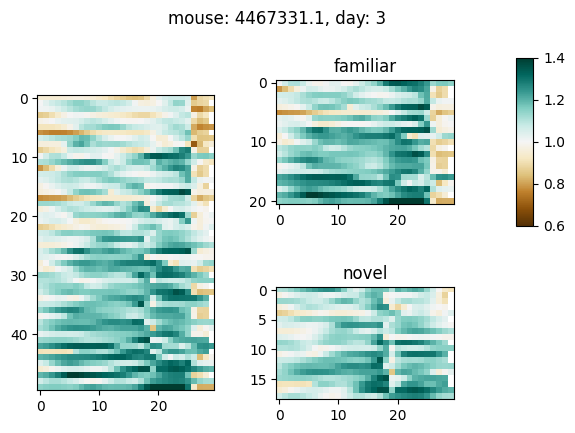

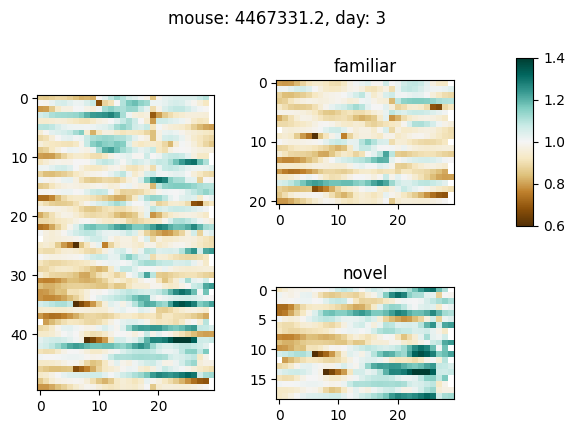

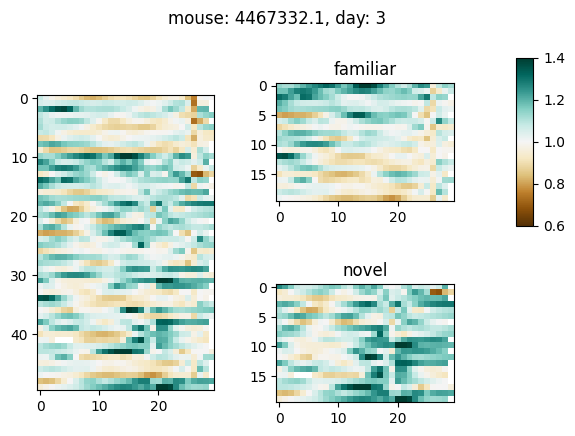

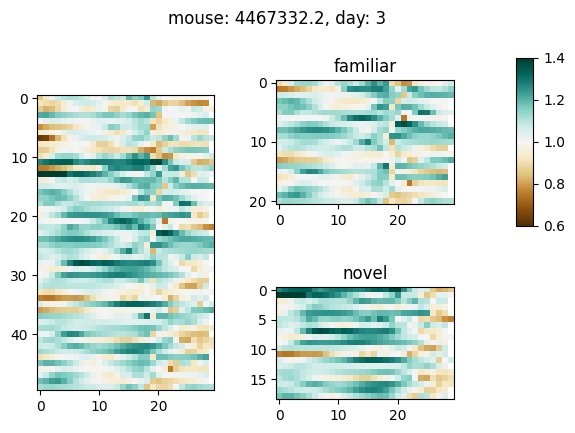

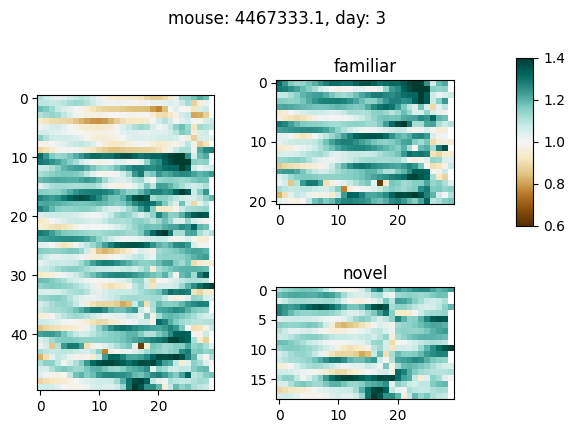

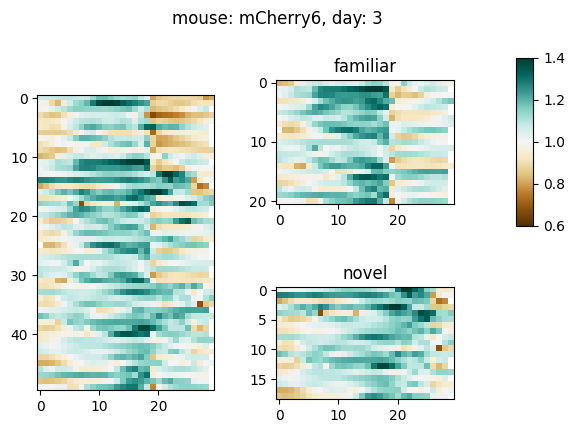

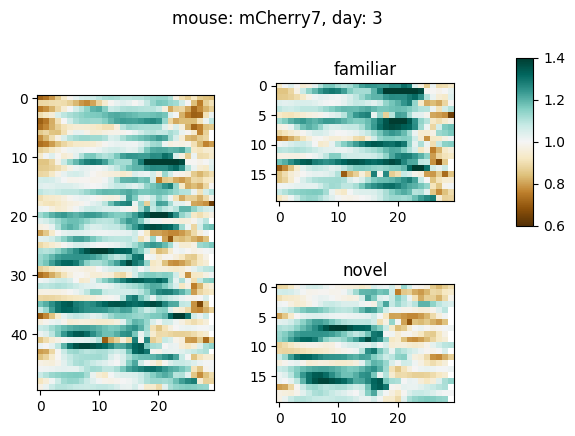

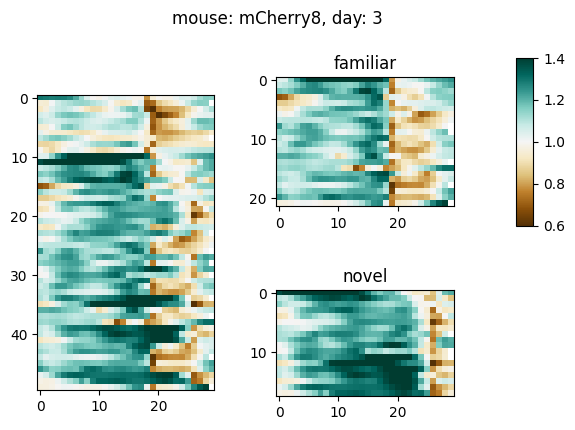

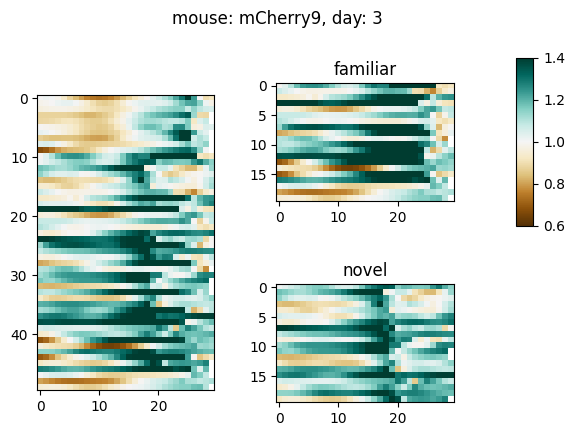

In [5]:
subdir =  figdir / 'single_sessions'
subdir.mkdir(exist_ok=True, parents=True)
for mouse in ctrl_mice:
    fig, ax = block_rate.plot_single_session('ctrl', mouse, 3, norm='population', cmap='BrBG', vmin=.6, vmax=1.4)

    fig.savefig(subdir / f'ctrl_{mouse}_day3_activity_rate.pdf')

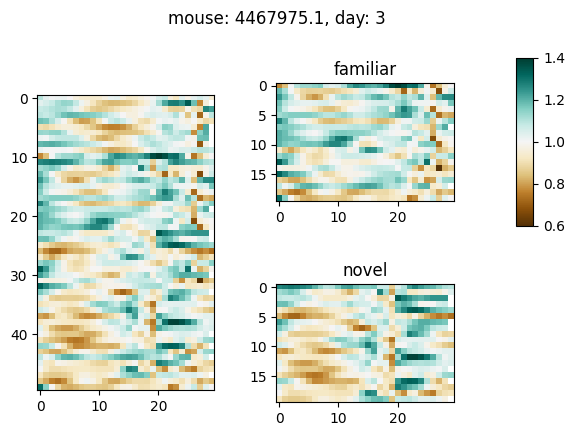

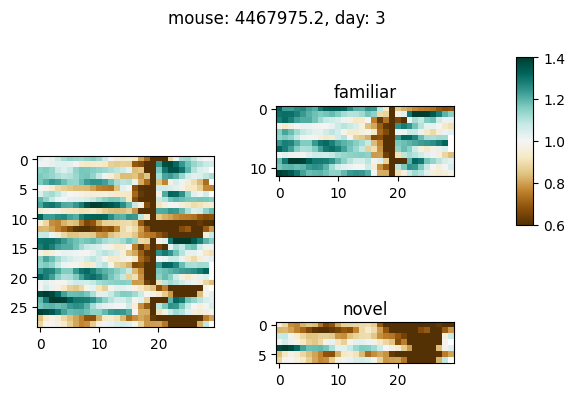

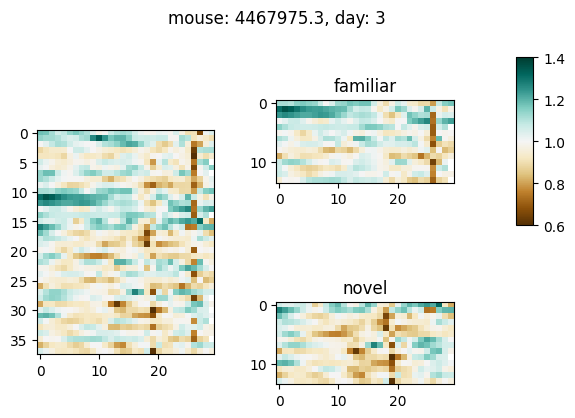

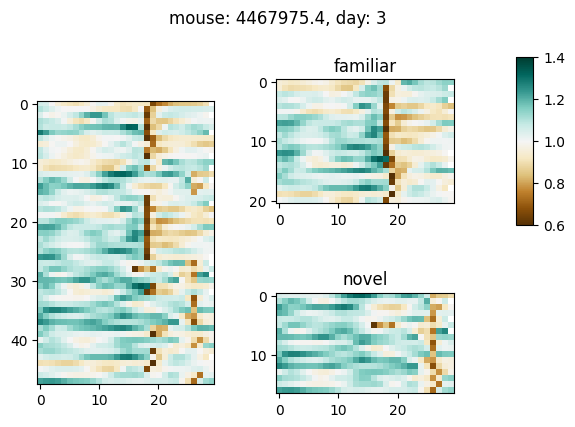

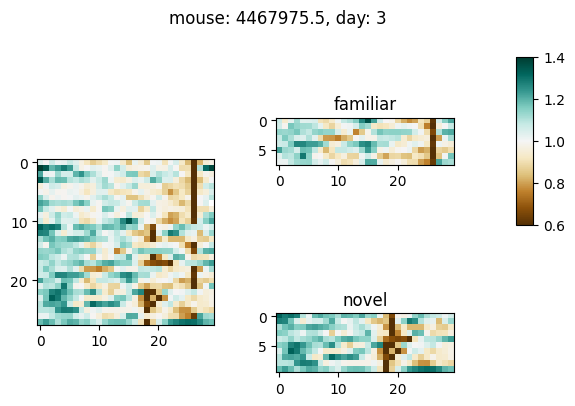

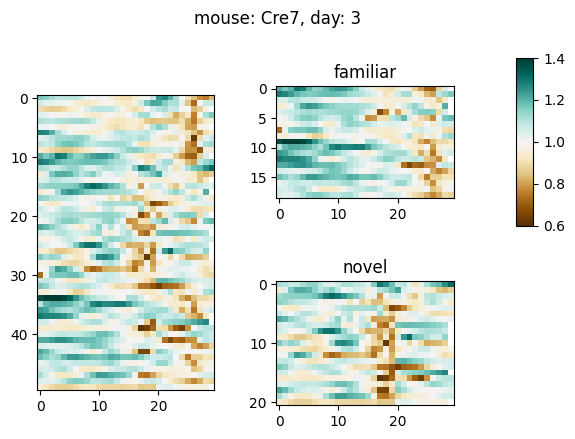

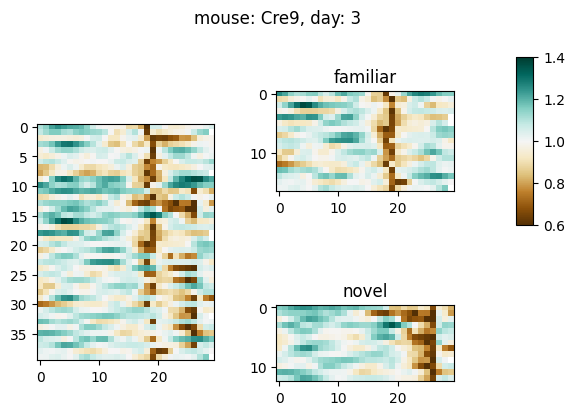

In [6]:
for mouse in ko_mice:
    fig, ax = block_rate.plot_single_session('ko', mouse, 3, norm='population', cmap='BrBG', vmin=.6, vmax=1.4)

    fig.savefig(subdir / f'ko_{mouse}_day3_activity_rate.pdf')

plot average activity, running speed and licks with no normalization

plot population normalized activity, speed and licks

linear model with activity or normalized activity

In [7]:
def plot_block_avg(block_rate, key='act', norm = 'population', max_trial=5):
    fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


    for day in np.arange(5):
        base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
        fam = {'ctrl': np.zeros([len(ctrl_mice),max_trial])*np.nan, 'ko': np.zeros([len(ko_mice),max_trial])*np.nan}
        nov = {'ctrl': np.zeros([len(ctrl_mice),max_trial])*np.nan, 'ko': np.zeros([len(ko_mice),max_trial])*np.nan}

        for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
            for i, mouse in enumerate(mice):
                data = block_rate.activity_rates[cond][mouse][day]

                if norm is None:

                    if key == 'act':
                       
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[cond][i,:_base.shape[0]] = _base
                    fam[cond][i,:_fam.shape[0]] = _fam
                    nov[cond][i,:_nov.shape[0]] = _nov

                elif norm == 'population':
                    if key == 'act':
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[cond][i,:_base.shape[0]] = _base/_base.mean()
                    fam[cond][i,:_fam.shape[0]] = _fam/_base.mean()
                    nov[cond][i,:_nov.shape[0]] = _nov/_base.mean()
                elif norm == 'cell':
                    cell_denom = data['baseline_avg_act']

                    _base = np.nanmean(np.nanmean(data[f'baseline_{key}']/cell_denom,axis=1),axis=-1)
                    base[cond][i,:_base.shape[0]] = _base

                    _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}']/cell_denom,axis=1),axis=-1)[:max_trial]
                    fam[cond][i,:_fam.shape[0]] = _fam

                    _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}']/cell_denom,axis=1), axis=-1)[:max_trial]
                    nov[cond][i,:_nov.shape[0]] = _nov

        for cond, color in zip(('ctrl','ko'), ('black', 'red')):
            x_base = np.arange(-10,0)
            mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
            ax[0,day].plot(x_base, mu, color=color)
            ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            ax[1,day].plot(x_base, mu, color=color)
            ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            x_block = np.arange(1,max_trial+1)
            mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
            ax[0,day].plot(x_block, mu, color=color)
            ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
            ax[1,day].plot(x_block, mu, color=color)
            ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            ax[0,day].set_title(f'familiar: day {day}')
            ax[1,day].set_title(f'novel: day {day}')

    for a in ax.flatten():
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        if key == 'act':
            a.set_ylabel('activity rate (dF/F)')
        else:
            a.set_ylabel(key)
        a.set_xlabel('Trial')
    return fig, ax

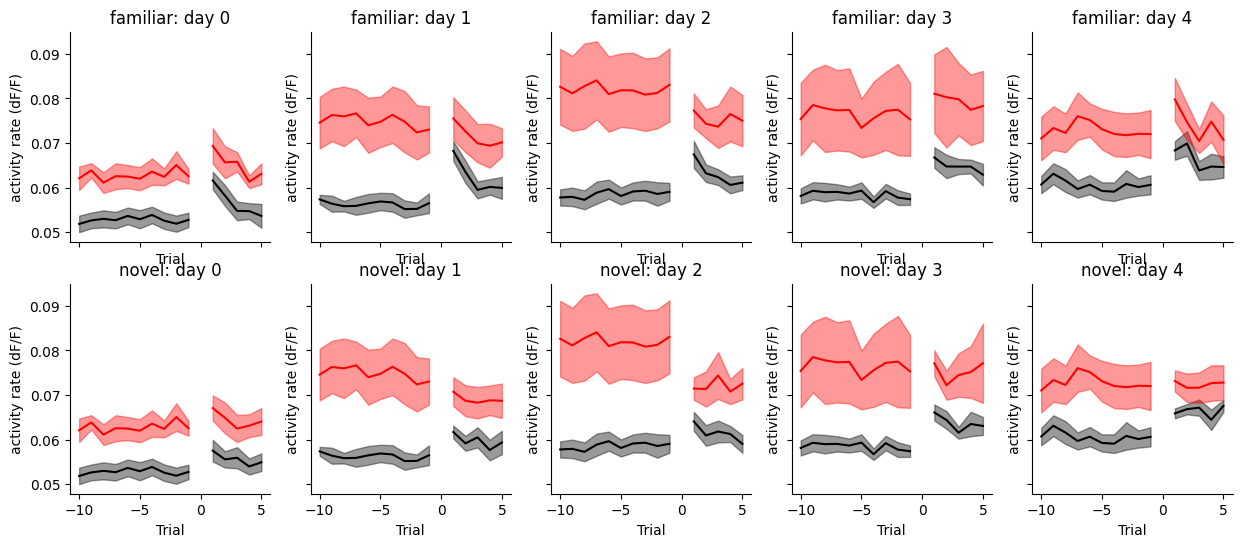

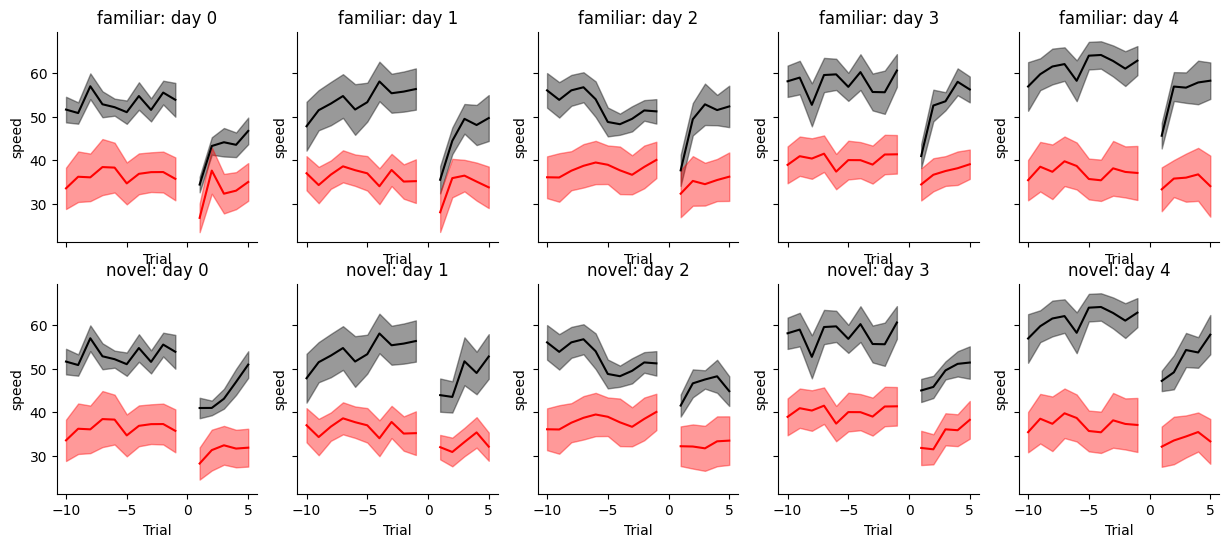

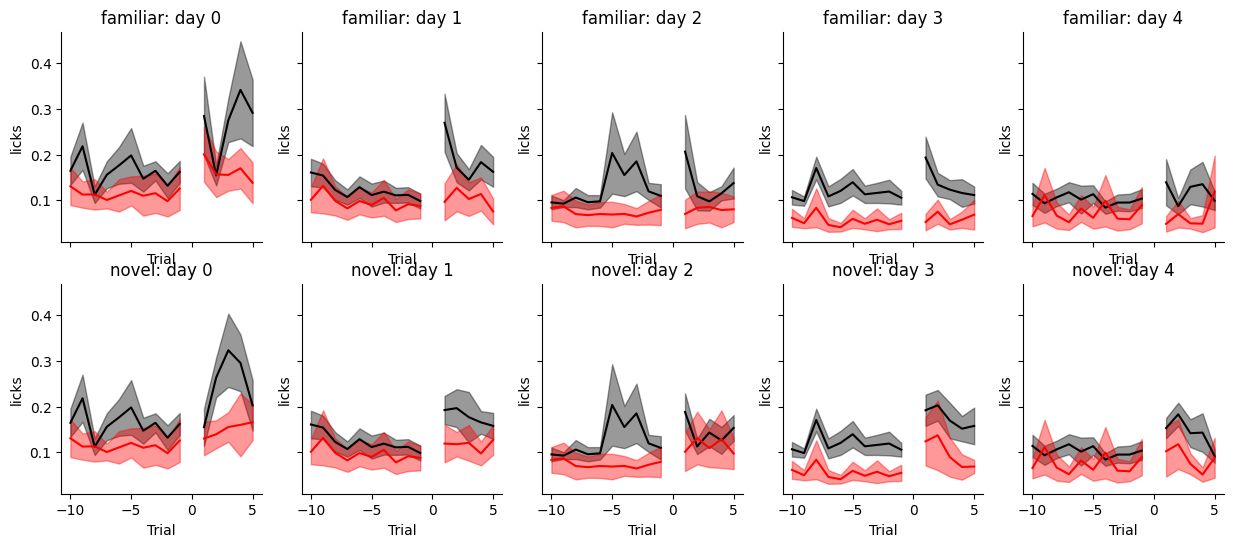

In [8]:
fig, ax = plot_block_avg(block_rate, norm = None, max_trial=5)
fig.savefig(figdir / 'last_block_activity_rate.pdf')
fig, ax = plot_block_avg(block_rate, key='speed', norm = None, max_trial=5)
fig.savefig(figdir / 'last_block_speed.pdf')
fig, ax = plot_block_avg(block_rate, key='licks', norm = None, max_trial=5)
fig.savefig(figdir / 'last_block_licks.pdf')

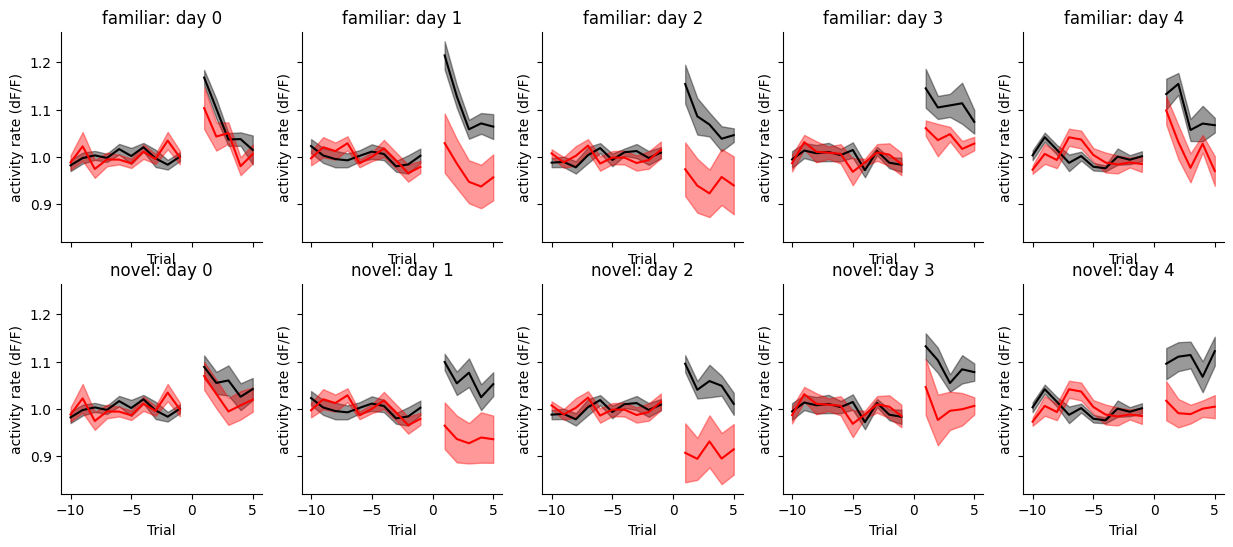

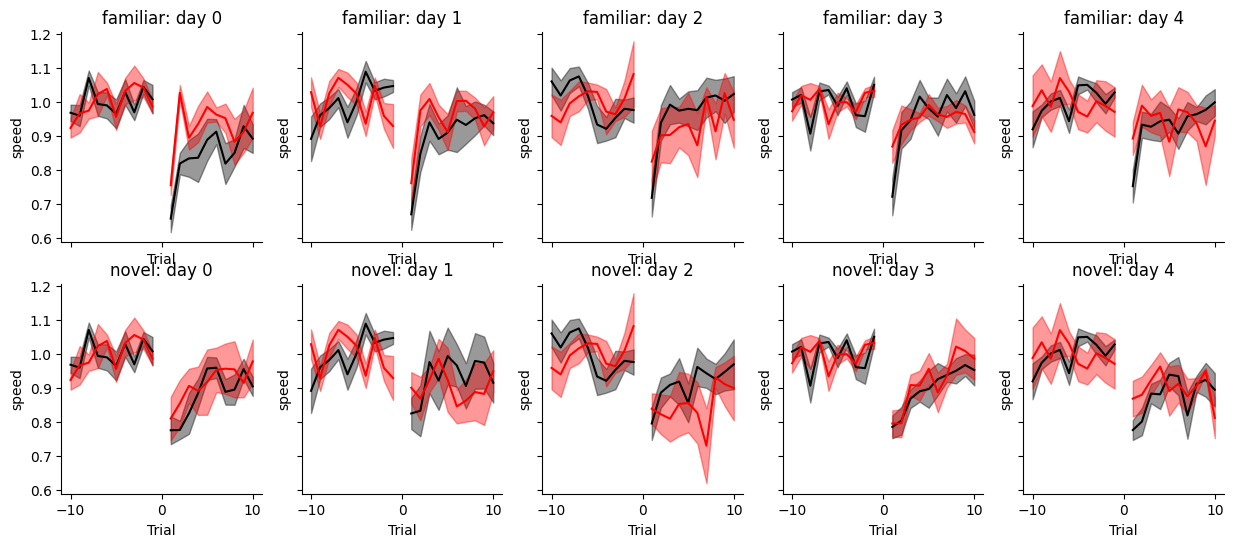

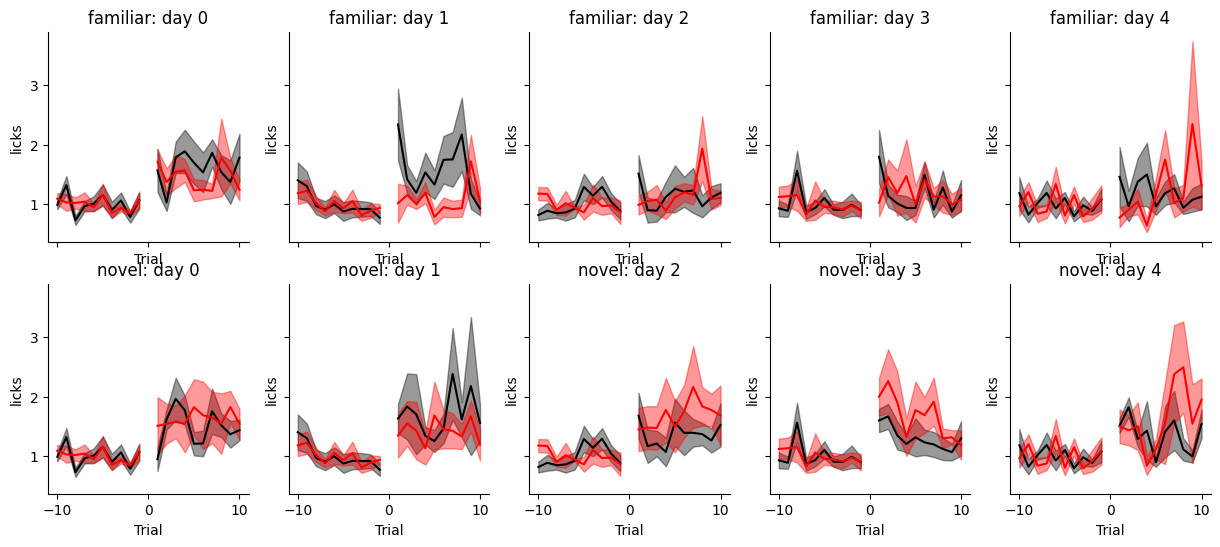

In [9]:
fig, ax = plot_block_avg(block_rate, norm = 'population', max_trial=5)
fig.savefig(figdir / 'last_block_activity_rate_population_norm.pdf')
fig, ax = plot_block_avg(block_rate, key='speed', norm = 'population', max_trial=10)
fig.savefig(figdir / 'last_block_speed_norm.pdf')
fig, ax = plot_block_avg(block_rate, key='licks', norm = 'population', max_trial=10)

In [10]:
df = block_rate.build_dataframe(max_trial=5, norm='population', norm_behavior=True)
df = df.loc[(df['day']<5) * df['ttype'].isin(('familiar', 'novel'))]

In [11]:
df['rank_rate'] = df['rate'].rank()


/tmp/ipykernel_501381/3123769972.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rank_rate'] = df['rate'].rank()


In [12]:
# Fit a mixed model on ranks
import statsmodels.formula.api as smf

model = smf.mixedlm("rank_rate ~ C(ttype) + C(condition) + C(day) + speed + licks", df, groups=df['mouse'])
model_result = model.fit()

In [13]:
model_result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
=================================================================
Model:                MixedLM    Dependent Variable:    rank_rate
No. Observations:     160        Method:                REML     
No. Groups:           16         Scale:                 1080.6756
Min. group size:      10         Log-Likelihood:        -762.9804
Max. group size:      10         Converged:             Yes      
Mean group size:      10.0                                       
-----------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------
Intercept          180.982   27.395  6.606 0.000  127.289 234.674
C(ttype)[T.novel]  -15.055    5.326 -2.827 0.005  -25.494  -4.616
C(condition)[T.ko] -52.712    8.569 -6.151 0.000  -69.508 -35.916
C(day)[T.1]         -2.471    8.288 -0.298 0.766  -18.716  13.774
C(day)[T.2]        -15.402    8.340 -1.847 0.065  -31.748   0.944
C(day)[T.3]         15.680    8.276  1.895 0.058   -0.541  31.902
C(day)[T.4]          8.051    8.382  0.961 0.337   -8.377  24.479
speed              -78.927   26.357 -2.995 0.003 -130.587 -27.268
licks               -0.849    5.189 -0.164 0.870  -11.019   9.321
Group Var          178.920    3.509                              
=================================================================

"""

In [14]:
model_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                 chi2                 P>chi2  df constraint
Intercept       [[43.64561808486719]]  3.935573471754879e-11              1
C(ttype)        [[7.989943682637696]]   0.004703787821732739              1
C(condition)    [[37.83602394894079]]  7.694766737106294e-10              1
C(day)          [[16.13986579676771]]   0.002837113739532354              4
speed           [[8.967270100853092]]   0.002748589703837072              1
licks         [[0.02677359696921981]]     0.8700252649594322              1

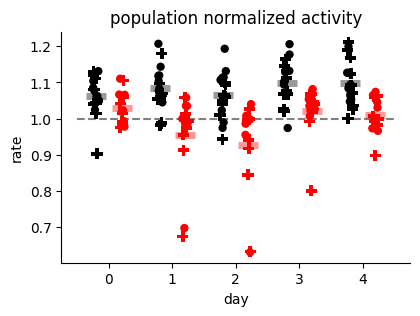

In [15]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)

sns.stripplot(data=df.loc[df['ttype']=='familiar',:],
            x='day',
            y='rate',
            hue='condition', 
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            dodge=True,
            alpha=1.,s=6,
            ax=ax,
            legend=False)

sns.stripplot(data=df.loc[df['ttype']=='novel',:],
            x='day',
            y='rate',
            hue='condition', 
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            marker='P', 
            dodge=True,
            alpha= 1., s=8, linewidth=0,
            ax=ax,
            legend=False)

sns.pointplot(data=df.loc[df['ttype'].isin(('familiar','novel')),:],
            x='day',
            y='rate',
            errorbar=None,
            estimator=np.mean,
            hue='condition',
            dodge = .4,
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,zorder=10,
            )


#
ax.set_title('population normalized activity')
ax.hlines(1,-.5,4.5, color='gray', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(figdir / 'novel_activity_rate_by_day.pdf', bbox_inches='tight')


In [ ]:
import statsmodels.formula.api as smf

df['speed_rank'] = df['speed'].rank()
model = smf.mixedlm("speed_rank ~ C(ttype) + C(condition) + C(day)", df, groups=df['mouse'])
model_result = model.fit()
model_result.summary()

/tmp/ipykernel_501381/3529737953.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['speed_rank'] = df['speed'].rank()
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


<class 'statsmodels.iolib.summary2.Summary'>
"""
                             Mixed Linear Model Regression Results
===============================================================================================
Model:                         MixedLM              Dependent Variable:              speed_rank
No. Observations:              160                  Method:                          REML      
No. Groups:                    16                   Scale:                           1886.5694 
Min. group size:               10                   Log-Likelihood:                  -752.0557 
Max. group size:               10                   Converged:                       Yes       
Mean group size:               10.0                                                            
-----------------------------------------------------------------------------------------------
                                                  Coef.  Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------------------------------------
Intercept                                         46.111   15.158  3.042 0.002   16.403  75.819
C(ttype)[T.novel]                                 13.778   20.475  0.673 0.501  -26.353  53.909
C(condition)[T.ko]                                51.032   22.916  2.227 0.026    6.117  95.947
C(day)[T.1]                                       17.111   20.475  0.836 0.403  -23.020  57.242
C(day)[T.2]                                       49.667   20.475  2.426 0.015    9.536  89.798
C(day)[T.3]                                       41.222   20.475  2.013 0.044    1.091  81.353
C(day)[T.4]                                       41.111   20.475  2.008 0.045    0.980  81.242
C(ttype)[T.novel]:C(condition)[T.ko]             -38.206   30.956 -1.234 0.217  -98.878  22.466
C(ttype)[T.novel]:C(day)[T.1]                     -1.333   28.956 -0.046 0.963  -58.087  55.420
C(ttype)[T.novel]:C(day)[T.2]                    -43.889   28.956 -1.516 0.130 -100.642  12.865
C(ttype)[T.novel]:C(day)[T.3]                    -38.000   28.956 -1.312 0.189  -94.754  18.754
C(ttype)[T.novel]:C(day)[T.4]                    -33.333   28.956 -1.151 0.250  -90.087  23.420
C(condition)[T.ko]:C(day)[T.1]                   -14.397   30.956 -0.465 0.642  -75.069  46.275
C(condition)[T.ko]:C(day)[T.2]                   -41.810   30.956 -1.351 0.177 -102.482  18.863
C(condition)[T.ko]:C(day)[T.3]                   -28.365   30.956 -0.916 0.360  -89.037  32.307
C(condition)[T.ko]:C(day)[T.4]                   -34.825   30.956 -1.125 0.261  -95.498  25.847
C(ttype)[T.novel]:C(condition)[T.ko]:C(day)[T.1]  25.190   43.778  0.575 0.565  -60.613 110.994
C(ttype)[T.novel]:C(condition)[T.ko]:C(day)[T.2]  38.317   43.778  0.875 0.381  -47.486 124.121
C(ttype)[T.novel]:C(condition)[T.ko]:C(day)[T.3]  24.714   43.778  0.565 0.572  -61.089 110.518
C(ttype)[T.novel]:C(condition)[T.ko]:C(day)[T.4]  44.619   43.778  1.019 0.308  -41.184 130.422
Group Var                                        181.211    3.095                              
===============================================================================================

"""

In [35]:
df['ttype']

1      familiar
2         novel
4      familiar
5         novel
7      familiar
         ...   
278       novel
280    familiar
281       novel
283    familiar
284       novel
Name: ttype, Length: 160, dtype: object

In [37]:
pg.pairwise_tests(data=df.loc[df['ttype']=='novel'], dv='speed_rank', within='day', between='condition',subject='mouse', parametric=False)

,Contrast,day,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,hedges
0,day,-,0,1,True,False,NaN,48.0,two-sided,0.322510,-0.366133
1,day,-,0,2,True,False,NaN,63.0,two-sided,0.820892,-0.083400
2,day,-,0,3,True,False,NaN,55.5,two-sided,0.534857,-0.033405
3,day,-,0,4,True,False,NaN,50.0,two-sided,0.365436,-0.253758
4,day,-,1,2,True,False,NaN,46.0,two-sided,0.265931,0.309402
5,day,-,1,3,True,False,NaN,41.0,two-sided,0.170313,0.375405
6,day,-,1,4,True,False,NaN,59.0,two-sided,0.660228,0.171474
7,day,-,2,3,True,False,NaN,66.5,two-sided,0.958754,0.058846
8,day,-,2,4,True,False,NaN,51.0,two-sided,0.393472,-0.180033
9,day,-,3,4,True,False,NaN,48.0,two-sided,0.313220,-0.256746


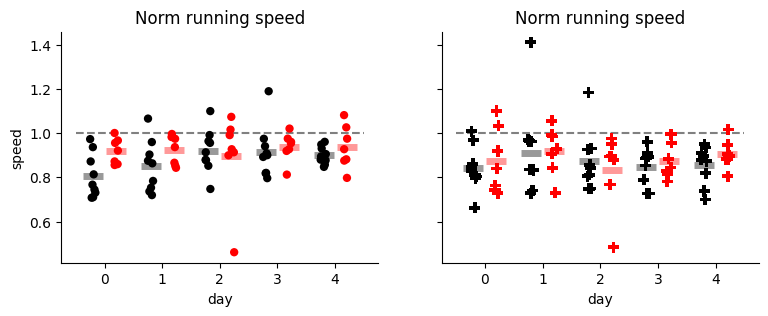

In [40]:
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey = True)

sns.stripplot(data=df.loc[df['ttype']=='familiar',:],
            x='day',
            y='speed',
            hue='condition', 
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            dodge=True,
            alpha=1.,s=6,
            ax=ax[0],
            legend=False)

sns.pointplot(data=df.loc[df['ttype']=='familiar',:],
            x='day',
            y='speed',
            errorbar=None,
            estimator=np.mean,
            hue='condition',
            dodge = .4,
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            ax=ax[0],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,zorder=10,
            )

sns.stripplot(data=df.loc[df['ttype']=='novel',:],
            x='day',
            y='speed',
            hue='condition', 
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            marker='P', 
            dodge=True,
            alpha= 1., s=8, linewidth=0,
            ax=ax[1],
            legend=False)

sns.pointplot(data=df.loc[df['ttype']=='novel',:],
            x='day',
            y='speed',
            errorbar=None,
            estimator=np.mean,
            hue='condition',
            dodge = .4,
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            ax=ax[1],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,zorder=10,
            )


#
for a in ax:
    a.set_title('Norm running speed')
    a.hlines(1,-.5,4.5, color='gray', linestyle='--')
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.savefig(figdir / 'novel_speed_by_day.pdf', bbox_inches='tight')


In [90]:
with open('/home/mplitt/shuffle_pkls/dense_novel_activity_mixedlm_shuffle.pkl', 'rb') as file:
    model_shuff_result = pickle.load(file)


In [91]:
for stat in model_shuff_result.keys():

    true_coef = model_shuff_result[stat]['genotype coef.']
    shuff_coefs = model_shuff_result[stat]['shuffle genotype coef.']
    p = (true_coef<shuff_coefs).sum()/float(shuff_coefs.shape[0])
    p = np.minimum(p, 1-p)
    print(f"{stat} true coef = {true_coef}, p = {p} ")


rate true coef = -0.10805892159341147, p = 8.741258741262747e-05 
rank_rate true coef = -56.33537097409627, p = 8.741258741262747e-05 


In [92]:
model_shuff_result['rank_rate']['true_model'].summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
================================================================
Model:               MixedLM    Dependent Variable:    rank_rate
No. Observations:    160        Method:                REML     
No. Groups:          16         Scale:                 1154.8942
Min. group size:     10         Log-Likelihood:        -769.8992
Max. group size:     10         Converged:             No       
Mean group size:     10.0                                       
----------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
----------------------------------------------------------------
Intercept          116.707   20.828  5.604 0.000  75.886 157.529
C(ttype)[T.novel]  -12.955    5.414 -2.393 0.017 -23.566  -2.344
C(condition)[T.ko] -56.335   10.435 -5.399 0.000 -76.788 -35.883
C(day)[T.1]         -7.059    8.875 -0.795 0.426 -24.453  10.335
C(day)[T.2]        -19.334    9.269 -2.086 0.037 -37.501  -1.167
C(day)[T.3]         10.910    9.388  1.162 0.245  -7.490  29.309
C(day)[T.4]          2.732    9.704  0.282 0.778 -16.287  21.751
speed                0.013    0.358  0.036 0.971  -0.688   0.714
licks              -21.521   38.672 -0.557 0.578 -97.316  54.274
Group Var          173.472    3.660                             
================================================================

"""

In [93]:
model_shuff_result['rank_rate']['true_model'].wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                   chi2                  P>chi2  df constraint
Intercept         [[31.39923918724904]]  2.1006320215921012e-08              1
C(ttype)          [[5.726034085832195]]    0.016715190167620603              1
C(condition)     [[29.145403781602994]]   6.714484211446056e-08              1
C(day)           [[14.071760947431223]]    0.007069511468191999              4
speed         [[0.0012932215608902242]]      0.9713131454528636              1
licks           [[0.30969762186632954]]      0.5778657959229376              1

In [8]:
block_rate_sparse = stx.novel_activity_rate.BlockTransitionActivityRate_Sparse(ts_key='F_dff')

SparseKO_02
SparseKO_06
SparseKO_08


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:306: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],


SparseKO_10


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:306: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:306: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:306: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],


SparseKO_11
SparseKO_13


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:306: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:306: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:306: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:306: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:306: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.

SparseKO_09


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:500: RuntimeWarning: Mean of empty slice
  comb = np.nanmean(np.concatenate((data['baseline_act'], data['block_act'])),axis=-1)/base.mean()
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:501: RuntimeWarning: Mean of empty slice
  fam = np.nanmean(data['block_fam_act'], axis=-1)/base.mean()
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:502: RuntimeWarning: Mean of empty slice
  nov = np.nanmean(data['block_nov_act'], axis=-1)/base.mean()


NameError: name 'subdir' is not defined

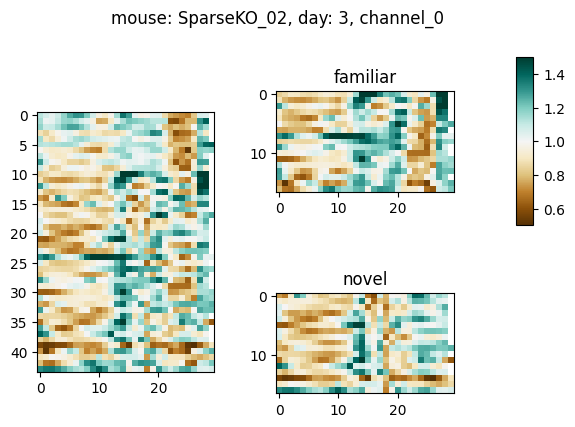

In [ ]:
for mouse in sparse_mice:
    fig, ax = block_rate_sparse.plot_single_session( mouse, 3, 'channel_0', norm='population', cmap='BrBG', vmin=.5, vmax=1.5)
    fig.savefig(subdir / f'sparse_{mouse}_channel0_day3_activity_rate.pdf')
    fig, ax = block_rate_sparse.plot_single_session( mouse, 3, 'channel_1', norm='population', cmap='BrBG', vmin=.5, vmax=1.5)
    fig.savefig(subdir / f'sparse_{mouse}_channel1_day3_activity_rate.pdf')
    

In [ ]:
def plot_block_avg_sparse(block_rate_sparse, key='act', norm = 'population', max_trial=5):
    fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


    for day in np.arange(5):
        base = {'channel_0': np.zeros([len(sparse_mice),10])*np.nan, 'channel_1': np.zeros([len(sparse_mice),10])*np.nan}
        fam = {'channel_0': np.zeros([len(sparse_mice),max_trial])*np.nan, 'channel_1': np.zeros([len(sparse_mice),max_trial])*np.nan}
        nov = {'channel_0': np.zeros([len(sparse_mice),max_trial])*np.nan, 'channel_1': np.zeros([len(sparse_mice),max_trial])*np.nan}

        for i, mouse in enumerate(sparse_mice):
            for chan in ('channel_0', 'channel_1'):
                if mouse == 'SparseKO_09' and day ==2:
                        continue
                
                data = block_rate_sparse.activity_rates[mouse][day][chan]

                if norm is None:

                    if key == 'act':
                       
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[chan][i,:_base.shape[0]] = _base
                    fam[chan][i,:_fam.shape[0]] = _fam
                    nov[chan][i,:_nov.shape[0]] = _nov

                elif norm == 'population':
                    if key == 'act':
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[chan][i,:_base.shape[0]] = _base/_base.mean()
                    fam[chan][i,:_fam.shape[0]] = _fam/_base.mean()
                    nov[chan][i,:_nov.shape[0]] = _nov/_base.mean()
                elif norm == 'cell':
                    cell_denom = data['baseline_avg_act']

                    _base = np.nanmean(np.nanmean(data[f'baseline_{key}']/cell_denom,axis=1),axis=-1)
                    base[chan][i,:_base.shape[0]] = _base

                    _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}']/cell_denom,axis=1),axis=-1)[:max_trial]
                    fam[chan][i,:_fam.shape[0]] = _fam

                    _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}']/cell_denom,axis=1), axis=-1)[:max_trial]
                    nov[chan][i,:_nov.shape[0]] = _nov

               

        for chan, color in zip(('channel_1','channel_0'), ('black', 'red')):
            x_base = np.arange(-10,0)
            mu, sem = np.nanmean(base[chan], axis=0), sp.stats.sem(base[chan],axis=0, nan_policy='omit')
            ax[0,day].plot(x_base, mu, color=color)
            ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            ax[1,day].plot(x_base, mu, color=color)
            ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            x_block = np.arange(1,max_trial+1)
            mu, sem = np.nanmean(fam[chan], axis=0), sp.stats.sem(fam[chan],axis=0, nan_policy='omit')
            ax[0,day].plot(x_block, mu, color=color)
            ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            mu, sem = np.nanmean(nov[chan], axis=0), sp.stats.sem(nov[chan],axis=0, nan_policy='omit')
            ax[1,day].plot(x_block, mu, color=color)
            ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            ax[0,day].set_title(f'familiar: day {day}')
            ax[1,day].set_title(f'novel: day {day}')

    for a in ax.flatten():
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        if key == 'act':
            a.set_ylabel('activity rate (dF/F)')
        else:
            a.set_ylabel(key)
        
        a.set_xlabel('Trial')
    return fig, ax

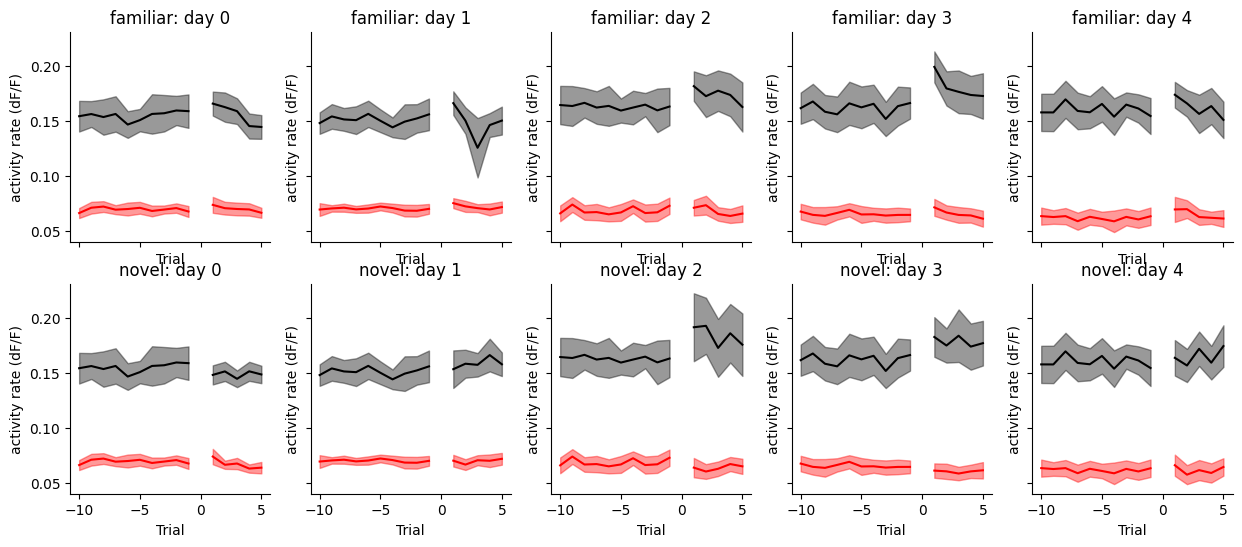

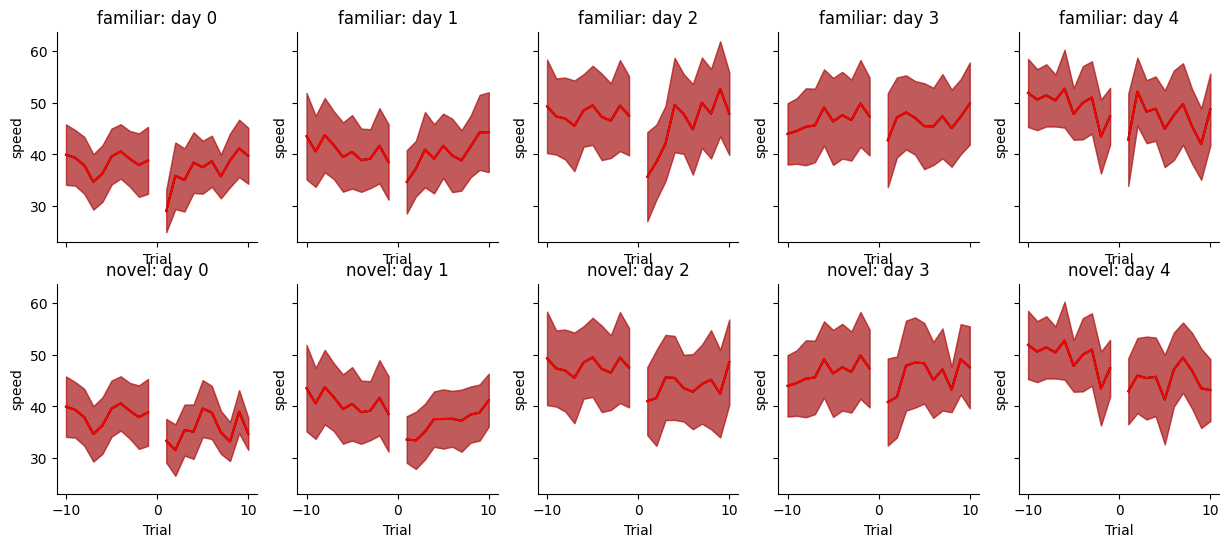

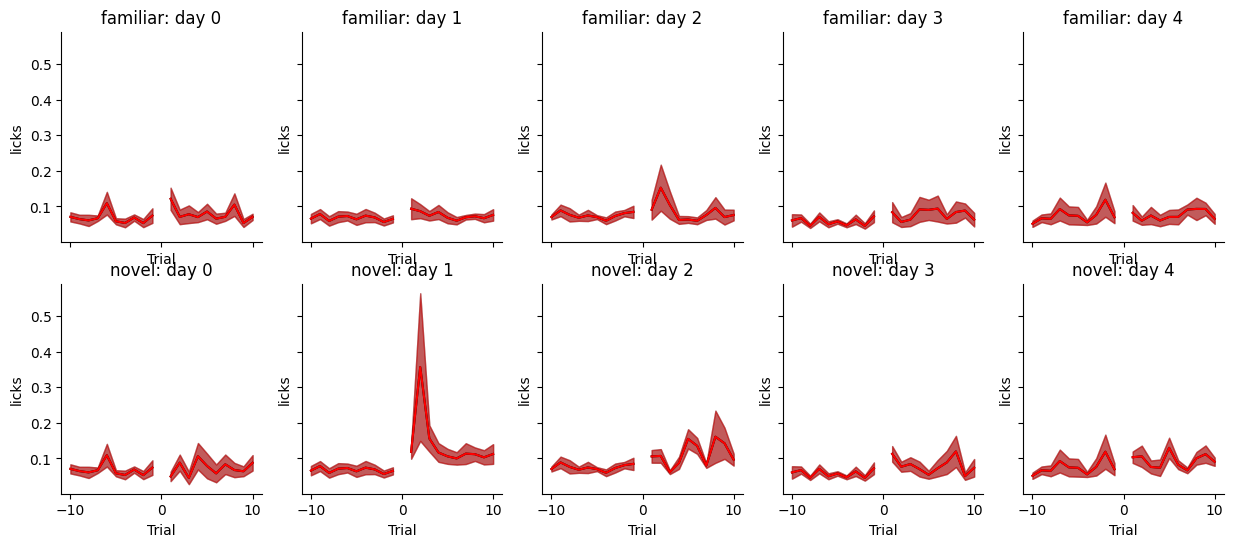

In [ ]:
fig, ax = plot_block_avg_sparse(block_rate_sparse, norm = None, max_trial=5)
fig.savefig(figdir / 'last_block_sparse_activity_rate.pdf')
fig, ax = plot_block_avg_sparse(block_rate_sparse, key='speed', norm = None, max_trial=10)

fig, ax = plot_block_avg_sparse(block_rate_sparse, key='licks', norm = None, max_trial=10)

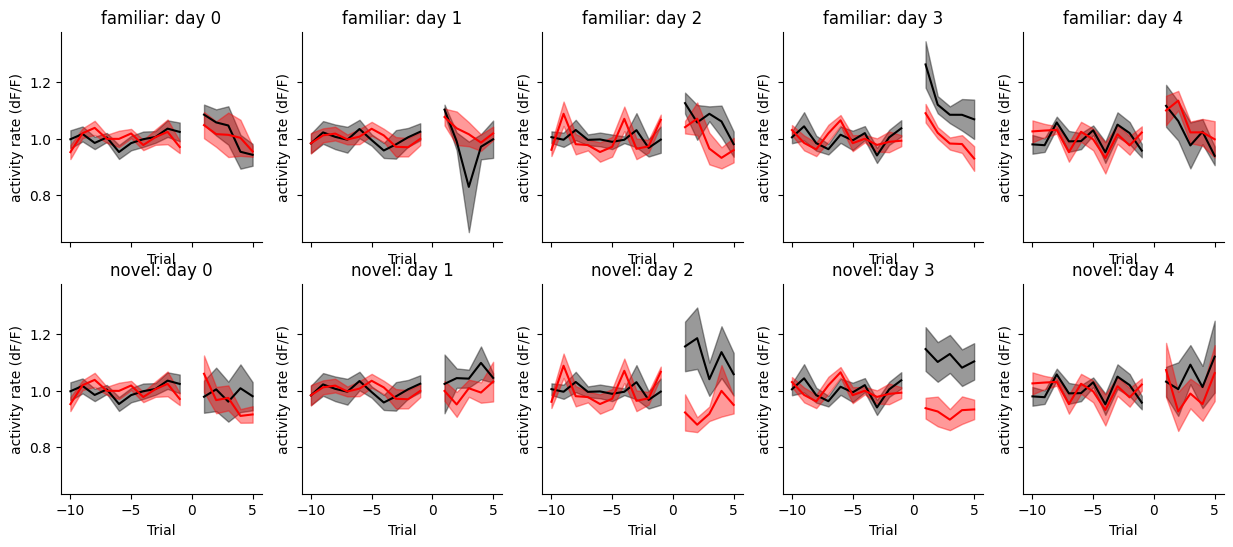

In [ ]:
fig, ax = plot_block_avg_sparse(block_rate_sparse, norm ='population', max_trial=5)
fig.savefig(figdir / 'last_block_sparse_activity_rate_population_norm.pdf')

In [10]:
with open('/home/mplitt/shuffle_pkls/sparse_novel_activity_mixedlm_shuffle.pkl', 'rb') as file:
    model_shuff_result = pickle.load(file)

In [11]:
for stat in model_shuff_result.keys():
    print(stat)
    true_coef_keys = model_shuff_result[stat]['genotype coef.'].keys()
    for key in true_coef_keys:

        true_coef = model_shuff_result[stat]['genotype coef.'][key]
        shuff_coefs = model_shuff_result[stat]['shuffle genotype coef.'][key]
        print("nans", np.isnan(shuff_coefs).sum())
        p = (true_coef<shuff_coefs).sum()/float(shuff_coefs.shape[0])
        p = np.minimum(p, 1-p)
        print(f"{key} true coef = {true_coef}, p = {p} ")

norm_rate
nans 117
C(channel)[T.channel_1] true coef = 0.0155068152232455, p = 0.374 
nans 117
C(channel)[T.channel_1]:C(day)[T.1] true coef = -0.012691251241561655, p = 0.489 
nans 117
C(channel)[T.channel_1]:C(day)[T.2] true coef = 0.10922983690705196, p = 0.086 
nans 117
C(channel)[T.channel_1]:C(day)[T.3] true coef = 0.13914639214047597, p = 0.039 
nans 117
C(channel)[T.channel_1]:C(day)[T.4] true coef = -0.005502615501449611, p = 0.478 
rank_norm_rate
nans 155
C(channel)[T.channel_1] true coef = 4.000000000000011, p = 0.399 
nans 155
C(channel)[T.channel_1]:C(day)[T.1] true coef = -5.357142857142868, p = 0.479 
nans 155
C(channel)[T.channel_1]:C(day)[T.2] true coef = 35.33333333333332, p = 0.047 
nans 155
C(channel)[T.channel_1]:C(day)[T.3] true coef = 47.42857142857142, p = 0.023 
nans 155
C(channel)[T.channel_1]:C(day)[T.4] true coef = -7.785714285714298, p = 0.479 


In [12]:
model_shuff_result['rank_norm_rate']['true_model'].summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                     Mixed Linear Model Regression Results
================================================================================
Model:                    MixedLM       Dependent Variable:       rank_norm_rate
No. Observations:         136           Method:                   REML          
No. Groups:               7             Scale:                    1312.4178     
Min. group size:          16            Log-Likelihood:           -643.0863     
Max. group size:          20            Converged:                Yes           
Mean group size:          19.4                                                  
--------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                            62.544   10.669  5.862 0.000  41.634 83.455
C(ttype)[T.novel]                   -12.088    6.213 -1.946 0.052 -24.265  0.089
C(channel)[T.channel_1]               4.000   13.693  0.292 0.770 -22.837 30.837
C(day)[T.1]                          13.000   13.693  0.949 0.342 -13.837 39.837
C(day)[T.2]                          -6.049   14.287 -0.423 0.672 -34.050 21.952
C(day)[T.3]                          -8.000   13.693 -0.584 0.559 -34.837 18.837
C(day)[T.4]                          16.857   13.693  1.231 0.218  -9.980 43.694
C(channel)[T.channel_1]:C(day)[T.1]  -5.357   19.364 -0.277 0.782 -43.310 32.596
C(channel)[T.channel_1]:C(day)[T.2]  35.333   20.155  1.753 0.080  -4.170 74.836
C(channel)[T.channel_1]:C(day)[T.3]  47.429   19.364  2.449 0.014   9.475 85.382
C(channel)[T.channel_1]:C(day)[T.4]  -7.786   19.364 -0.402 0.688 -45.739 30.168
Group Var                            73.004    2.274                            
================================================================================

"""

In [13]:
model_shuff_result['rank_norm_rate']['true_model'].converged

True

In [14]:
model_shuff_result['rank_norm_rate']['true_model'].wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                     chi2                P>chi2  df constraint
Intercept           [[34.36700236562011]]  4.56395849887404e-09              1
C(ttype)            [[3.785581679502662]]   0.05169593913306747              1
C(channel)          [[0.085338679237905]]    0.7701888757007495              1
C(day)              [[5.233393634443182]]   0.26417706777873684              4
C(channel):C(day)  [[13.603309673837735]]    0.0086749218039266              4

In [15]:
df = block_rate_sparse.build_dataframe()
df = df.loc[(df['day']<5) * df['ttype'].isin(('familiar', 'novel'))]
df['rank_rate'] = df['rate'].rank()

In [18]:
model = smf.mixedlm("rank_rate ~ C(ttype) + C(channel) + C(day)", df, groups=df['mouse'])
model_result = model.fit()

model_result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
               Mixed Linear Model Regression Results
====================================================================
Model:                 MixedLM     Dependent Variable:     rank_rate
No. Observations:      136         Method:                 REML     
No. Groups:            7           Scale:                  1414.7571
Min. group size:       16          Log-Likelihood:         -664.7204
Max. group size:       20          Converged:              Yes      
Mean group size:       19.4                                         
--------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------
Intercept                55.897    9.002  6.209 0.000  38.253 73.541
C(ttype)[T.novel]       -12.088    6.451 -1.874 0.061 -24.731  0.555
C(channel)[T.channel_1]  17.294    6.451  2.681 0.007   4.651 29.937
C(day)[T.1]              10.321   10.053  1.027 0.305  -9.381 30.024
C(day)[T.2]              11.583   10.511  1.102 0.270  -9.017 32.183
C(day)[T.3]              15.714   10.053  1.563 0.118  -3.988 35.417
C(day)[T.4]              12.964   10.053  1.290 0.197  -6.738 32.667
Group Var                67.966    2.190                            
====================================================================

"""

In [19]:
model_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                              chi2                P>chi2  df constraint
Intercept   [[38.553976205195944]]   5.3260152400323e-10              1
C(ttype)      [[3.51174386477171]]   0.06093528452192823              1
C(channel)   [[7.187764521768298]]  0.007340237187309706              1
C(day)       [[2.842693521135794]]     0.584485759126947              4

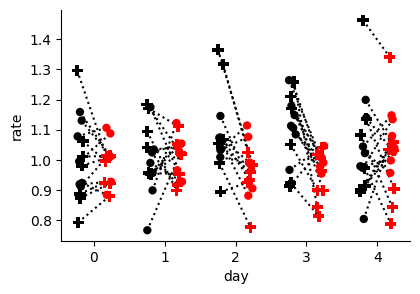

In [20]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
df = block_rate_sparse.df.loc[(block_rate_sparse.df['day']<5) * (block_rate_sparse.df['ttype']=='familiar'),:]

sns.stripplot(data=df,
            x='day',
            y='rate',
            hue='channel', 
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            dodge=True, s=6,
            ax=ax,
            legend=False)

df = block_rate_sparse.df.loc[(block_rate_sparse.df['day']<5) * (block_rate_sparse.df['ttype']=='novel'),:]

sns.stripplot(data=df,
            x='day',
            y='rate',
            hue='channel', 
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            marker='P', s=8,
            dodge=True,
            ax=ax,
            legend=False)
for d in range(0,20,2):
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.savefig(figdir / 'sparse_last_block_activity_rate_by_day.pdf')


In [21]:
res = pg.pairwise_tests(block_rate_sparse.df.loc[(block_rate_sparse.df['day']<5)], 
                        dv='rate',
                        within=['day', 'channel'],
                        subject='mouse',
                        parametric=False, padjust='holm')

res

,Contrast,day,A,B,Paired,Parametric,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,day,-,0,1,True,False,6.0,two-sided,0.43750,1.00000,holm,-0.529100
1,day,-,0,2,True,False,7.0,two-sided,0.56250,1.00000,holm,-0.543545
2,day,-,0,3,True,False,5.0,two-sided,0.31250,1.00000,holm,-0.637445
3,day,-,0,4,True,False,1.0,two-sided,0.06250,0.62500,holm,-0.655185
4,day,-,1,2,True,False,8.0,two-sided,0.68750,1.00000,holm,-0.111180
5,day,-,1,3,True,False,10.0,two-sided,1.00000,1.00000,holm,-0.128258
6,day,-,1,4,True,False,8.0,two-sided,0.68750,1.00000,holm,-0.298017
7,day,-,2,3,True,False,9.0,two-sided,0.84375,1.00000,holm,0.015209
8,day,-,2,4,True,False,10.0,two-sided,1.00000,1.00000,holm,-0.182240
9,day,-,3,4,True,False,7.0,two-sided,0.56250,1.00000,holm,-0.221259
